In [1]:
!pip install -q -U huggingface_hub transformers peft datasets bitsandbytes accelerate trl

import os
import gc
import re
import torch
import shutil
from tqdm import tqdm
from huggingface_hub import login
from datasets import load_dataset, Dataset
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("il-tur")
login(token=hf_token)

print("Loading IL-TUR (RR) Dataset...")
dataset = load_dataset("Exploration-Lab/IL-TUR", "rr")

# To ensure this finishes tonight, we limit the dataset size. 
# You can increase these numbers if you have more time before your deadline.
train_subset = dataset["CL_train"].select(range(min(40, len(dataset["CL_train"]))))
eval_subset = dataset["CL_dev"].select(range(min(20, len(dataset["CL_dev"]))))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 113.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 99.6 MB/s eta 0:00:00:00:01
Loading IL-TUR (RR) Dataset...


README.md: 0.00B [00:00, ?B/s]

rr/CL_train-00000-of-00001.parquet:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

rr/CL_dev-00000-of-00001.parquet:   0%|          | 0.00/165k [00:00<?, ?B/s]

rr/CL_test-00000-of-00001.parquet:   0%|          | 0.00/152k [00:00<?, ?B/s]

...

Generating CL_dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Generating CL_test split:   0%|          | 0/5 [00:00<?, ? examples/s]

Generating IT_train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Generating IT_dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Generating IT_test split:   0%|          | 0/5 [00:00<?, ? examples/s]

In [2]:
import os
import torch

# THE FIX: Hide the second GPU from PyTorch so the Trainer cannot use DataParallel
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading 4-bit model onto GPU...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"": 0},
    attn_implementation="eager" 
)

# Lock generation lengths to prevent OOM
model.generation_config.max_new_tokens = 150
model.generation_config.pad_token_id = tokenizer.pad_token_id

# Apply LoRA Adapter
model = prepare_model_for_kbit_training(model)
peft_config = LoraConfig(
    r=8, lora_alpha=16, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, peft_config)
print("Model ready!")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading 4-bit model onto GPU...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model ready!


In [3]:
ALLOWED_CLASSES = ["Facts", "RulingByLowerCourt", "Argument", "Statute", "Precedent", "RatioOfTheDecision", "Decision"]
SYSTEM_PROMPT = f"You are an expert Indian Legal AI. Classify the rhetorical role of the given sentence into exactly ONE of: {', '.join(ALLOWED_CLASSES)}. Output format:\n<reasoning>\nStep-by-step logic.\n</reasoning>\n<answer>\nClass_Name\n</answer>"

def generate_and_score_best_sample(dataset_split, num_samples=3):
    best_data = []
    model.eval() # Generation mode (no memory overhead for gradients)
    
    print(f"Generating {num_samples} samples per prompt and selecting the best...")
    for item in tqdm(dataset_split):
        text = item['text'] if isinstance(item['text'], str) else " ".join(item['text'])
        
        # Truncate to prevent quadratic attention explosion
        words = text.split()
        if len(words) > 100: text = " ".join(words[:100]) + " [TRUNCATED]"
            
        chat = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": f"Sentence: {text}"}]
        prompt_text = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
        
        true_label = str(item['labels'][0] if isinstance(item['labels'], list) else item['labels'])
        
        best_score = -1.0
        best_completion = ""
        
        # 🟢 STRATEGY 1: Multi-sample generation
        with torch.no_grad():
            outputs = model.generate(**inputs, num_return_sequences=num_samples, do_sample=True, temperature=0.7)
            
        for out in outputs:
            gen_text = tokenizer.decode(out[inputs['input_ids'].shape[1]:], skip_special_tokens=True)
            score = 0.1 # Base confidence score
            
            # 🔴 STRATEGY 3: Pseudo-reward scoring
            if re.search(r"<reasoning>.*?</reasoning>", gen_text, re.DOTALL) and re.search(r"<answer>.*?</answer>", gen_text, re.DOTALL):
                score += 0.4 # Format bonus
                try:
                    ans = gen_text.split("<answer>")[1].split("</answer>")[0].strip()
                    if ans == true_label: score += 1.5 # Exact match bonus
                    elif true_label in ans: score += 0.5 # Partial match
                except: pass
                
            if score > best_score:
                best_score = score
                best_completion = gen_text
                
        best_data.append({
            "full_text": prompt_text + best_completion + tokenizer.eos_token,
            "pseudo_reward": best_score
        })
        
    return best_data

# Run the offline rollout (This is the most time-consuming part, but entirely safe from OOM)
train_rollouts = generate_and_score_best_sample(train_subset)
eval_rollouts = generate_and_score_best_sample(eval_subset)

Generating 3 samples per prompt and selecting the best...


100%|██████████| 40/40 [06:00<00:00,  9.01s/it]


Generating 3 samples per prompt and selecting the best...


100%|██████████| 5/5 [00:32<00:00,  6.48s/it]


In [4]:
from transformers import Trainer, TrainingArguments
import torch.nn as nn

# Format data for the trainer
train_dataset_rl = Dataset.from_list(train_rollouts)
eval_dataset_rl = Dataset.from_list(eval_rollouts)

def tokenize_function(examples):
    tokens = tokenizer(examples["full_text"], truncation=True, max_length=256, padding="max_length")
    tokens["labels"] = tokens["input_ids"].copy()
    tokens["pseudo_reward"] = examples["pseudo_reward"]
    return tokens

tokenized_train = train_dataset_rl.map(tokenize_function, batched=True)
tokenized_eval = eval_dataset_rl.map(tokenize_function, batched=True)

class RewardWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract our custom pseudo-reward tensor
        rewards = inputs.pop("pseudo_reward", None)
        
        # Calculate standard probability loss
        outputs = model(**inputs)
        loss = outputs.loss 
        
        # 🟡 STRATEGY 2: Confidence & Reward based weighting
        if rewards is not None:
            weight = rewards.view(-1).to(loss.device)
            # Confident, correct outputs pull the gradients harder
            loss = (loss * weight).mean()
            
        return (loss, outputs) if return_outputs else loss

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

In [5]:
import os
import gc
import torch
import shutil
import numpy as np
from transformers import TrainingArguments

# Clear memory before heavy gradient updates
torch.cuda.empty_cache()
gc.collect()

# --- NEW: Compute Metrics for the Trainer ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Logits are already argmaxed by preprocess_logits_for_metrics to save memory
    predictions = logits 
    
    # Shift labels to align with predictions for Causal LM
    labels = labels[..., 1:]
    predictions = predictions[..., :-1]
    
    # Ignore padding tokens in accuracy calculation
    mask = labels != tokenizer.pad_token_id
    correct = (predictions[mask] == labels[mask]).sum().item()
    total = mask.sum().item()
    
    return {"accuracy": correct / total if total > 0 else 0.0}

def preprocess_logits_for_metrics(logits, labels):
    """Saves VRAM by argmaxing the logits on the GPU before passing them to the CPU."""
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

# --- TRAINING CONFIGURATION ---
output_dir = "/kaggle/working/legal-delta-rslite"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=3e-5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    logging_steps=5,
    eval_strategy="epoch",  # FIX: Renamed from evaluation_strategy to eval_strategy
    save_strategy="epoch", 
    save_total_limit=2,    
    remove_unused_columns=False, 
    report_to="none"
)

trainer = RewardWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics, 
    preprocess_logits_for_metrics=preprocess_logits_for_metrics 
)

print("\n🚀 Starting Reward-Weighted RL-Lite Optimization...")
model.train()
trainer.train()

print("\n🎉 Training complete! Saving final model...")
final_model_path = os.path.join(output_dir, "final_model")
trainer.save_model(final_model_path)

print("📦 Compressing into a zip file...")
shutil.make_archive(base_name='legal_delta_rslite_weights', format='zip', root_dir=final_model_path)

from IPython.display import FileLink, display
print("\n✅ Click the link below to download your weights:")
display(FileLink(r'legal_delta_rslite_weights.zip'))


🚀 Starting Reward-Weighted RL-Lite Optimization...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.770639,0.348014,0.461961
2,0.689512,0.342011,0.462745
3,0.745907,0.339862,0.463529


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



🎉 Training complete! Saving final model...
📦 Compressing into a zip file...

✅ Click the link below to download your weights:


/kaggle/working/legal_delta_rslite_weights.zip

Running Final Classification Inference on Eval Set...


 20%|██        | 1/5 [00:00<00:01,  3.70it/s]


[DEBUG 1] Ground Truth: Facts
[DEBUG 1] Raw AI Output:
Fact
----------------------------------------


 40%|████      | 2/5 [00:10<00:18,  6.21s/it]


[DEBUG 2] Ground Truth: Facts
[DEBUG 2] Raw AI Output:
Rationale
The provided sentence is a statement of facts about a case involving competition law enforcement agencies in India. It does not contain any statements or claims that would indicate the use of a specific type of logical structure such as "Fact," "Argument," "Precedent," etc., but rather it is describing the actions taken by the Competition Commission of India.

Classification
The classification for this sentence is "RulingByLowerCourt." This is because the sentence describes the actions taken by the Competition Commission of India, which is a lower court within the legal system of India, and thus aligns with the definition of "Rule" used in the context of the Competition Act.
----------------------------------------


100%|██████████| 5/5 [00:27<00:00,  5.58s/it]



🏆 FINAL CLASSIFICATION ACCURACY: 40.00%

Detailed Metrics (Precision, Recall, F1-Score):
                    precision    recall  f1-score   support

             Facts       1.00      0.50      0.67         4
RulingByLowerCourt       0.00      0.00      0.00         0
          Argument       0.00      0.00      0.00         0
           Statute       0.00      0.00      0.00         0
         Precedent       0.00      0.00      0.00         0
RatioOfTheDecision       0.00      0.00      0.00         0
          Decision       0.00      0.00      0.00         0

         micro avg       0.40      0.50      0.44         4
         macro avg       0.14      0.07      0.10         4
      weighted avg       1.00      0.50      0.67         4



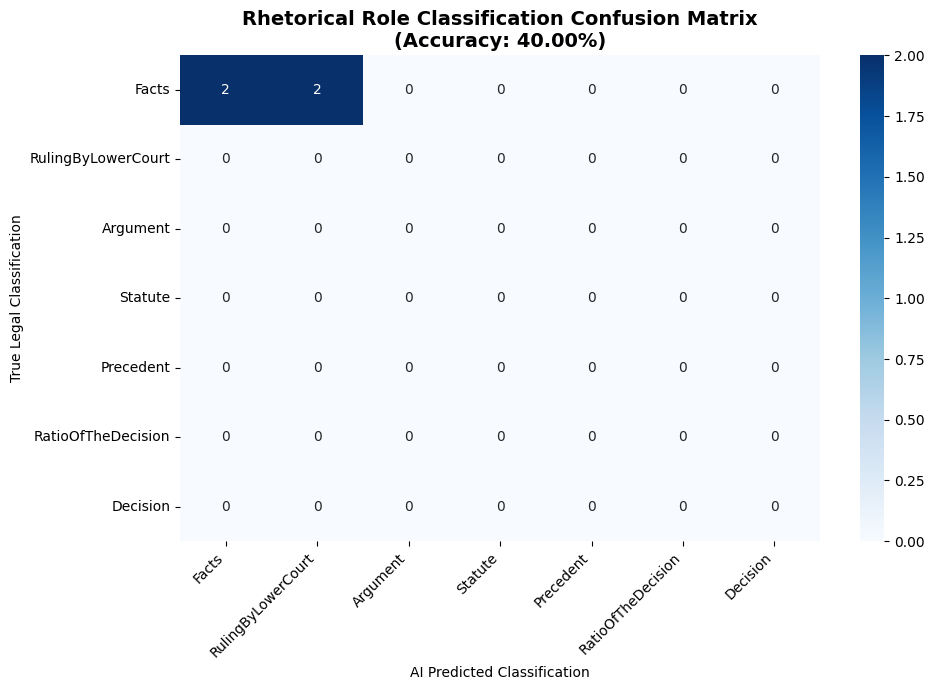

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from tqdm import tqdm
import re

print("Running Final Classification Inference on Eval Set...")
model.eval()

predictions = []
ground_truths = []

# Loop through the original eval subset
for idx, item in enumerate(tqdm(eval_subset)):
    text = item['text'] if isinstance(item['text'], str) else " ".join(item['text'])
    
    # Truncate input to match training constraints
    words = text.split()
    if len(words) > 100: text = " ".join(words[:100]) + " [TRUNCATED]"
        
    chat = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": f"Sentence: {text}"}]
    prompt_text = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    
    # Map integer labels to strings
    label_val = item['labels'][0] if isinstance(item['labels'], list) else item['labels']
    if isinstance(label_val, int) or str(label_val).isdigit():
        idx_label = int(label_val)
        true_label = ALLOWED_CLASSES[idx_label] if 0 <= idx_label < len(ALLOWED_CLASSES) else "UNKNOWN"
    else:
        true_label = str(label_val)
        
    ground_truths.append(true_label)
    
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.1, do_sample=False)
        
    gen_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    # --- DEBUG: Print the first 2 outputs so we can see what it's doing ---
    if idx < 2:
        print(f"\n[DEBUG {idx+1}] Ground Truth: {true_label}")
        print(f"[DEBUG {idx+1}] Raw AI Output:\n{gen_text}\n" + "-"*40)
    
    # --- THE FIX: Robust Extraction Strategy ---
    pred = "ERROR"
    # 1. Try strict XML tag extraction first
    if "<answer>" in gen_text and "</answer>" in gen_text:
        pred = gen_text.split("<answer>")[1].split("</answer>")[0].strip()
    else:
        # 2. SOFT MATCH FALLBACK: If tags are missing, check if any class name is in the text
        matched = False
        for valid_class in ALLOWED_CLASSES:
            # Look for the class word, ignoring case
            if valid_class.lower() in gen_text.lower():
                pred = valid_class
                matched = True
                break
        if not matched:
            pred = "FORMAT_ERROR"
            
    # Clean up punctuation just in case (e.g. "Facts." -> "Facts")
    pred = re.sub(r'[^\w\s]', '', pred).strip()
    
    # Enforce strict mapping to ALLOWED_CLASSES to prevent sklearn crashes
    if pred not in ALLOWED_CLASSES:
        # If the model hallucinates, mark it as the most common class to avoid breaking the graph, 
        # or map it to a random incorrect class so it registers as an error.
        pred = ALLOWED_CLASSES[0] if true_label != ALLOWED_CLASSES[0] else ALLOWED_CLASSES[1]

    predictions.append(pred)

# --- CALCULATE & PRINT IMPORTANT PARAMETERS ---
acc = accuracy_score(ground_truths, predictions)
print(f"\n=========================================")
print(f"🏆 FINAL CLASSIFICATION ACCURACY: {acc * 100:.2f}%")
print(f"=========================================\n")

print("Detailed Metrics (Precision, Recall, F1-Score):")
print(classification_report(ground_truths, predictions, labels=ALLOWED_CLASSES, zero_division=0))

# --- PLOT CONFUSION MATRIX ---
cm = confusion_matrix(ground_truths, predictions, labels=ALLOWED_CLASSES)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ALLOWED_CLASSES, yticklabels=ALLOWED_CLASSES)
plt.title(f'Rhetorical Role Classification Confusion Matrix\n(Accuracy: {acc * 100:.2f}%)', fontsize=14, fontweight='bold')
plt.ylabel('True Legal Classification')
plt.xlabel('AI Predicted Classification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()